# Wildfire Prediction with PyTorch

## Download and Extract the Wildfire Prediction Dataset form Kaggle

The project uses "Wildfire Prediction Dataset (Satelite Images)" from Kaggel (abdelghaniaaba). The dataset contains 42 850 satelite images of size 350x350 pixels RGB divided in two classes 22 710 assigned wildfire and 20 140 assigned nowildfire. 

The images are obtained from documented wildfires of more than 0.01 acres from the Canadian Government open dataportal.

The dataset is divided into 70% training, 15% validation and 15% test.

In [1]:
# Get dataset from kaggle
import kagglehub

path = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")
print(path)

C:\Users\malin\.cache\kagglehub\datasets\abdelghaniaaba\wildfire-prediction-dataset\versions\1


In [2]:
# Copy dataset to project file
import shutil
from pathlib import Path

dest = Path("data/wildfire_dataset")
if not dest.exists():
    shutil.copytree(path, dest)
    print(f"Kopierade till {dest.resolve()}")
else:
    print(f"{dest} alreday exists, no need to copy")

data\wildfire_dataset alreday exists, no need to copy


## Exploratory Data Analysis

In [3]:
# Look at dataset size
import pandas as pd
from pathlib import Path

rows = []
for split in ["train", "valid", "test"]:
    for cls in ["wildfire", "nowildfire"]:
        folder = Path(f"data/wildfire_dataset/{split}/{cls}")
        for file in folder.iterdir():
            rows.append({"split": split, "class": cls})

df = pd.DataFrame(rows)
df.value_counts(["split", "class"])

split  class     
train  wildfire      15750
       nowildfire    14499
valid  wildfire       3480
test   wildfire       3479
valid  nowildfire     2820
test   nowildfire     2820
Name: count, dtype: int64

In [4]:
# Check image shape for all images
import numpy as np
from PIL import Image

shapes = set()

# Save potentially broken files
broken_files = []

# Loop trough images
for split in ["train", "valid", "test"]:
    for cls in ["wildfire", "nowildfire"]:
        folder = Path(f"data/wildfire_dataset/{split}/{cls}")
        for file in folder.iterdir():
            try:
                with Image.open(file) as img:
                    shapes.add(np.array(img).shape)
            except OSError as e:
                broken_files.append((file, str(e)))

print(shapes)
print(f"\nFound {len(broken_files)} broken files:")
for file, error in broken_files:
    print(file, "_", error)

{(350, 350, 3)}

Found 0 broken files:


In [5]:
# Remove potentially broken files
for file, _ in broken_files:
    file.unlink()
    print(f"Tog bort {file}")

In [6]:
# Check dataset size after removing potentially broken files
rows = []
for split in ["train", "valid", "test"]:
    for cls in ["wildfire", "nowildfire"]:
        folder = Path(f"data/wildfire_dataset/{split}/{cls}")
        for file in folder.iterdir():
            rows.append({"split": split, "class": cls})

df = pd.DataFrame(rows)
df.value_counts(["split", "class"])

split  class     
train  wildfire      15750
       nowildfire    14499
valid  wildfire       3480
test   wildfire       3479
valid  nowildfire     2820
test   nowildfire     2820
Name: count, dtype: int64

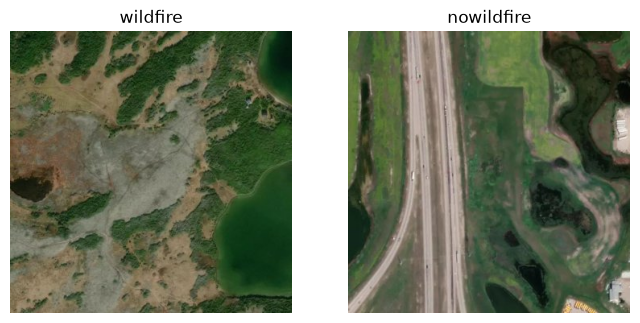

In [7]:
# Look at example images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, cls in zip(axes, ["wildfire", "nowildfire"]):
    folder = Path("data/wildfire_dataset/train") / cls
    first_file = list(folder.iterdir())[0]
    img = Image.open(first_file)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.show()

## Preprocess the Input Images Using Transforms

In [8]:
# Preprocessing to be applied to train, valid and test.
from torchvision import transforms

image_transform = {
    "train": transforms.Compose([
                  transforms.Resize(224),                   # Resize the image to 224×224 pixels.
                  transforms.RandomHorizontalFlip(p=0.5),   # Augmentation fliping the image
                  transforms.RandomRotation(degrees=15),    # Augmentation rotating the image
                  transforms.ToTensor(),                    # Convert the image to PyTorch Tensor data type.
                  transforms.Normalize(
                  mean=[0.485, 0.456, 0.406],               # Normalize the image with imagenet mean and std.
                  std=[0.229, 0.224, 0.225])
    ]),
        "valid": transforms.Compose([
                  transforms.Resize(224),
                  transforms.ToTensor(),
                  transforms.Normalize(
                  mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
    ]),
        "test": transforms.Compose([
                  transforms.Resize(224),
                  transforms.ToTensor(),
                  transforms.Normalize(
                  mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
    ])
}

## Dataset Preparation

In [9]:
# Loading data
from torch.utils.data import DataLoader
from torchvision import datasets

# Setting directory paths
data_root = Path("data/wildfire_dataset")
train_directory = data_root / "train"
valid_directory = data_root / "valid"
test_directory = data_root / "test"

# Batch size
batch_size = 32

# Number of classes
num_classes = len(list(valid_directory.iterdir()))
print(f"Number of classes: {num_classes}")

# Load data from folders
data = {
    "train": datasets.ImageFolder(root=train_directory, transform = image_transform["train"]),
    "valid": datasets.ImageFolder(root=valid_directory, transform = image_transform["valid"]),
    "test": datasets.ImageFolder(root=test_directory, transform = image_transform["test"]),
}

# Gett mapping of indices to class names
idx_to_class = {v: k for k, v in data["train"].class_to_idx.items()}
print(f"Index and class name: {idx_to_class}")

# Size of datasets
train_data_size = len(data["train"])
valid_data_size = len(data["valid"])
test_data_size = len(data["test"])
print (f"Training dataset size: {train_data_size}")
print (f"Validation dataset size: {valid_data_size}")
print (f"Test dataset size: {test_data_size}")

# Iterators for loading data
train_data_loader = DataLoader(data["train"], batch_size=batch_size, shuffle=True)
valid_data_loader = DataLoader(data["valid"], batch_size=batch_size, shuffle=False)
test_data_loader = DataLoader(data["test"], batch_size=batch_size, shuffle=False)

Number of classes: 2
Index and class name: {0: 'nowildfire', 1: 'wildfire'}
Training dataset size: 30249
Validation dataset size: 6300
Test dataset size: 6299


In [10]:
# Check the shape after preprocessing
images, labels = next(iter(train_data_loader))
print(f"Image shape: {images.shape}")
print(f"Image type: {images.dtype}")
print(f"Check of labels in one batch: {labels.shape, labels}")

Image shape: torch.Size([32, 3, 224, 224])
Image type: torch.float32
Check of labels in one batch: (torch.Size([32]), tensor([1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 1, 1]))


## Load the ResNet18 Pre-Trained Model

In [11]:
# Set the choise of device
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [12]:
# Load pretrained ResNet18 Model
from torchvision import models

resnet18 = models.resnet18(weights='DEFAULT')
resnet18 = resnet18.to(device)

In [13]:
# Check the model architecture
print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Freeze/Unfreeze

In [14]:
# Freeze model parameters
for param in resnet18.parameters():
    param.requires_grad = False

In [15]:
# Unfreeze and configure classification layer
import torch.nn as nn

# Change the final fully connected layer of the ResNet18 model for transfer learning
fc_inputs = resnet18.fc.in_features  # Get the number of input features for the final layer

# Define a new fully connected layer with custom architecture for classification
resnet18.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),  # Fully connected layer with 256 neurons
    nn.ReLU(),  # Apply ReLU activation
    nn.Dropout(0.4),  # Apply dropout with 40% probability to prevent overfitting
    nn.Linear(256, num_classes),  # Output layer with number of classes as output neurons
)

# Move the model to the appropriate device (either CUDA or CPU)
resnet18 = resnet18.to(device)

## Training Configuration

In [16]:
# Define the loss function fro classification
loss_func = nn.CrossEntropyLoss()

# Define the optimizer and learning rate
optimizer = torch.optim.Adam(
    (p for p in resnet18.parameters() if p.requires_grad),
    lr=0.001
)

## Model Training Function

In [17]:
import time as time

def model_compile_and_fit(model, loss_func, optimizer, epochs=10):
    """Function to train and validate"""

    start_time = time.time()
    history = []
    best_loss = 100000.0
    best_epoch = None

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch, epochs))

        # Set to training mode only for last layer
        model.eval()
        model.fc.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        for i, (inputs, labels) in enumerate(train_data_loader):
            # Sending images and labels to device
            inputs = inputs.to(device) 
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))
            acc = torch.mean(correct_counts.type(torch.FloatTensor))
            train_acc += acc.item() * inputs.size(0)

        with torch.no_grad():
            model.eval()

            for j, (inputs, labels) in enumerate(valid_data_loader):
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = loss_func(outputs, labels)
                valid_loss += loss.item() * inputs.size(0)
                ret, predictions = torch.max(outputs.data, 1)
                correct_counts = predictions.eq(labels.data.view_as(predictions))
                acc = torch.mean(correct_counts.type(torch.FloatTensor))
                valid_acc += acc.item() * inputs.size(0)

            if valid_loss < best_loss:
                best_loss = valid_loss
                best_epoch = epoch

                # Save if the model has best accuracy till now
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "idx_to_class": idx_to_class,
                }, "best_model.pt")

        # Find average training loss and training accuracy
        avg_train_loss = train_loss/train_data_size
        avg_train_acc = train_acc/train_data_size

        # Find average training loss and training accuracy
        avg_valid_loss = valid_loss/valid_data_size
        avg_valid_acc = valid_acc/valid_data_size

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss - {:.4f}, Accuracy - {:.4f}%, \n\t\tValidation : Loss - {:.4f}, Accuracy - {:.4f}%, Time: {:.4f}s".format(epoch, avg_train_loss, avg_train_acc*100, avg_valid_loss, avg_valid_acc*100, epoch_end-epoch_start))

    print(f"Total time: {(time.time() - start_time)/60:.1f} min")

    return model, history, best_epoch


## Run Training

In [18]:
model, history, best_epoch = model_compile_and_fit(resnet18, loss_func, optimizer, epochs=10)
history = np.array(history)

Epoch: 0/10
Epoch : 000, Training: Loss - 0.1754, Accuracy - 93.2361%, 
		Validation : Loss - 0.1356, Accuracy - 94.6190%, Time: 1033.6077s
Epoch: 1/10
Epoch : 001, Training: Loss - 0.1454, Accuracy - 94.3668%, 
		Validation : Loss - 0.1234, Accuracy - 95.0952%, Time: 1006.7028s
Epoch: 2/10
Epoch : 002, Training: Loss - 0.1344, Accuracy - 94.8263%, 
		Validation : Loss - 0.1390, Accuracy - 94.5397%, Time: 1004.4716s
Epoch: 3/10
Epoch : 003, Training: Loss - 0.1304, Accuracy - 95.1635%, 
		Validation : Loss - 0.1090, Accuracy - 96.0000%, Time: 999.1868s
Epoch: 4/10
Epoch : 004, Training: Loss - 0.1250, Accuracy - 95.3189%, 
		Validation : Loss - 0.1087, Accuracy - 95.8571%, Time: 957.1166s
Epoch: 5/10
Epoch : 005, Training: Loss - 0.1209, Accuracy - 95.4478%, 
		Validation : Loss - 0.1066, Accuracy - 95.9524%, Time: 939.0568s
Epoch: 6/10
Epoch : 006, Training: Loss - 0.1174, Accuracy - 95.5701%, 
		Validation : Loss - 0.1044, Accuracy - 96.0952%, Time: 926.4542s
Epoch: 7/10
Epoch : 007,

## Plot the Training Logs

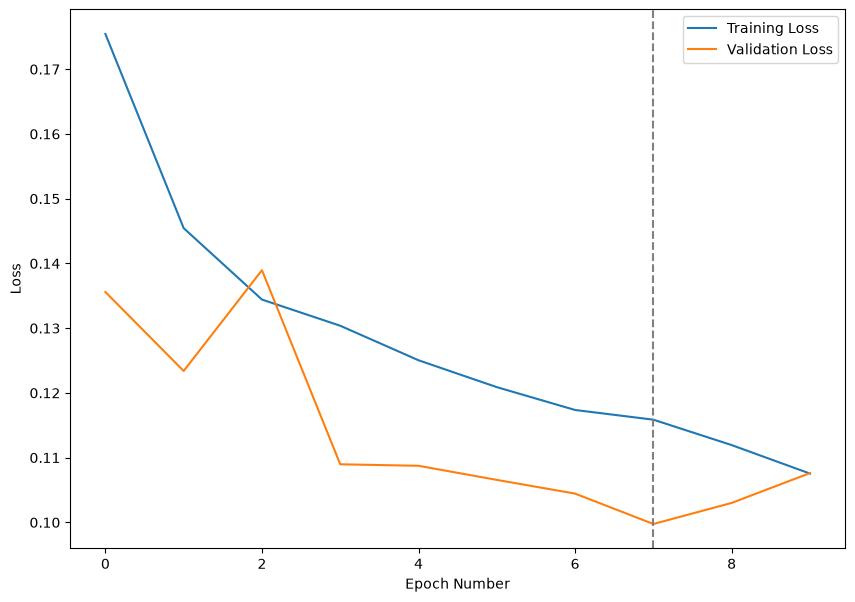

In [19]:
plt.figure(figsize=(10, 7))
plt.plot(history[:,0:2])
plt.legend(["Training Loss", "Validation Loss"])
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.axvline(best_epoch, linestyle="--", color="gray")
plt.savefig("loss_curve.png")
plt.show()

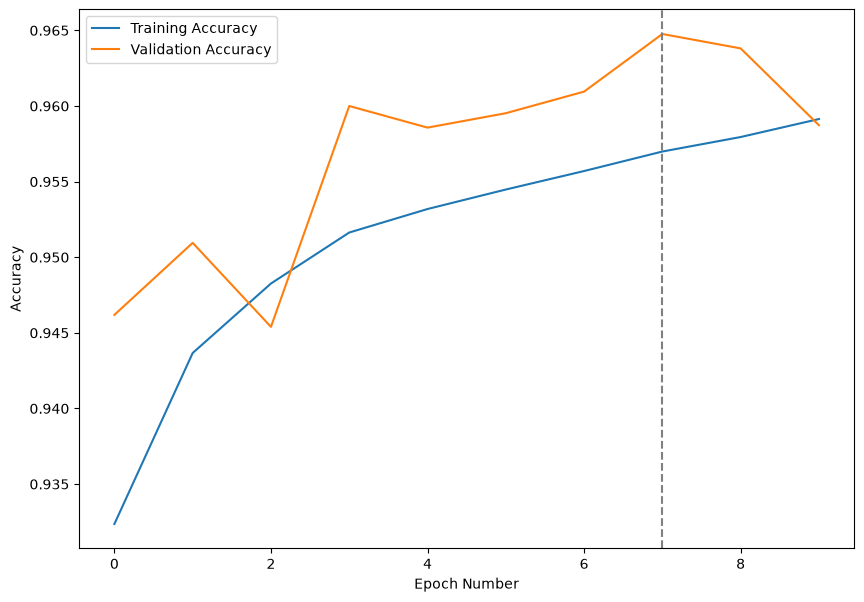

In [20]:
plt.figure(figsize=(10, 7))
plt.plot(history[:,2:4])
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.axvline(best_epoch, linestyle="--", color="gray")
plt.savefig("accuracy_curve.png")
plt.show()